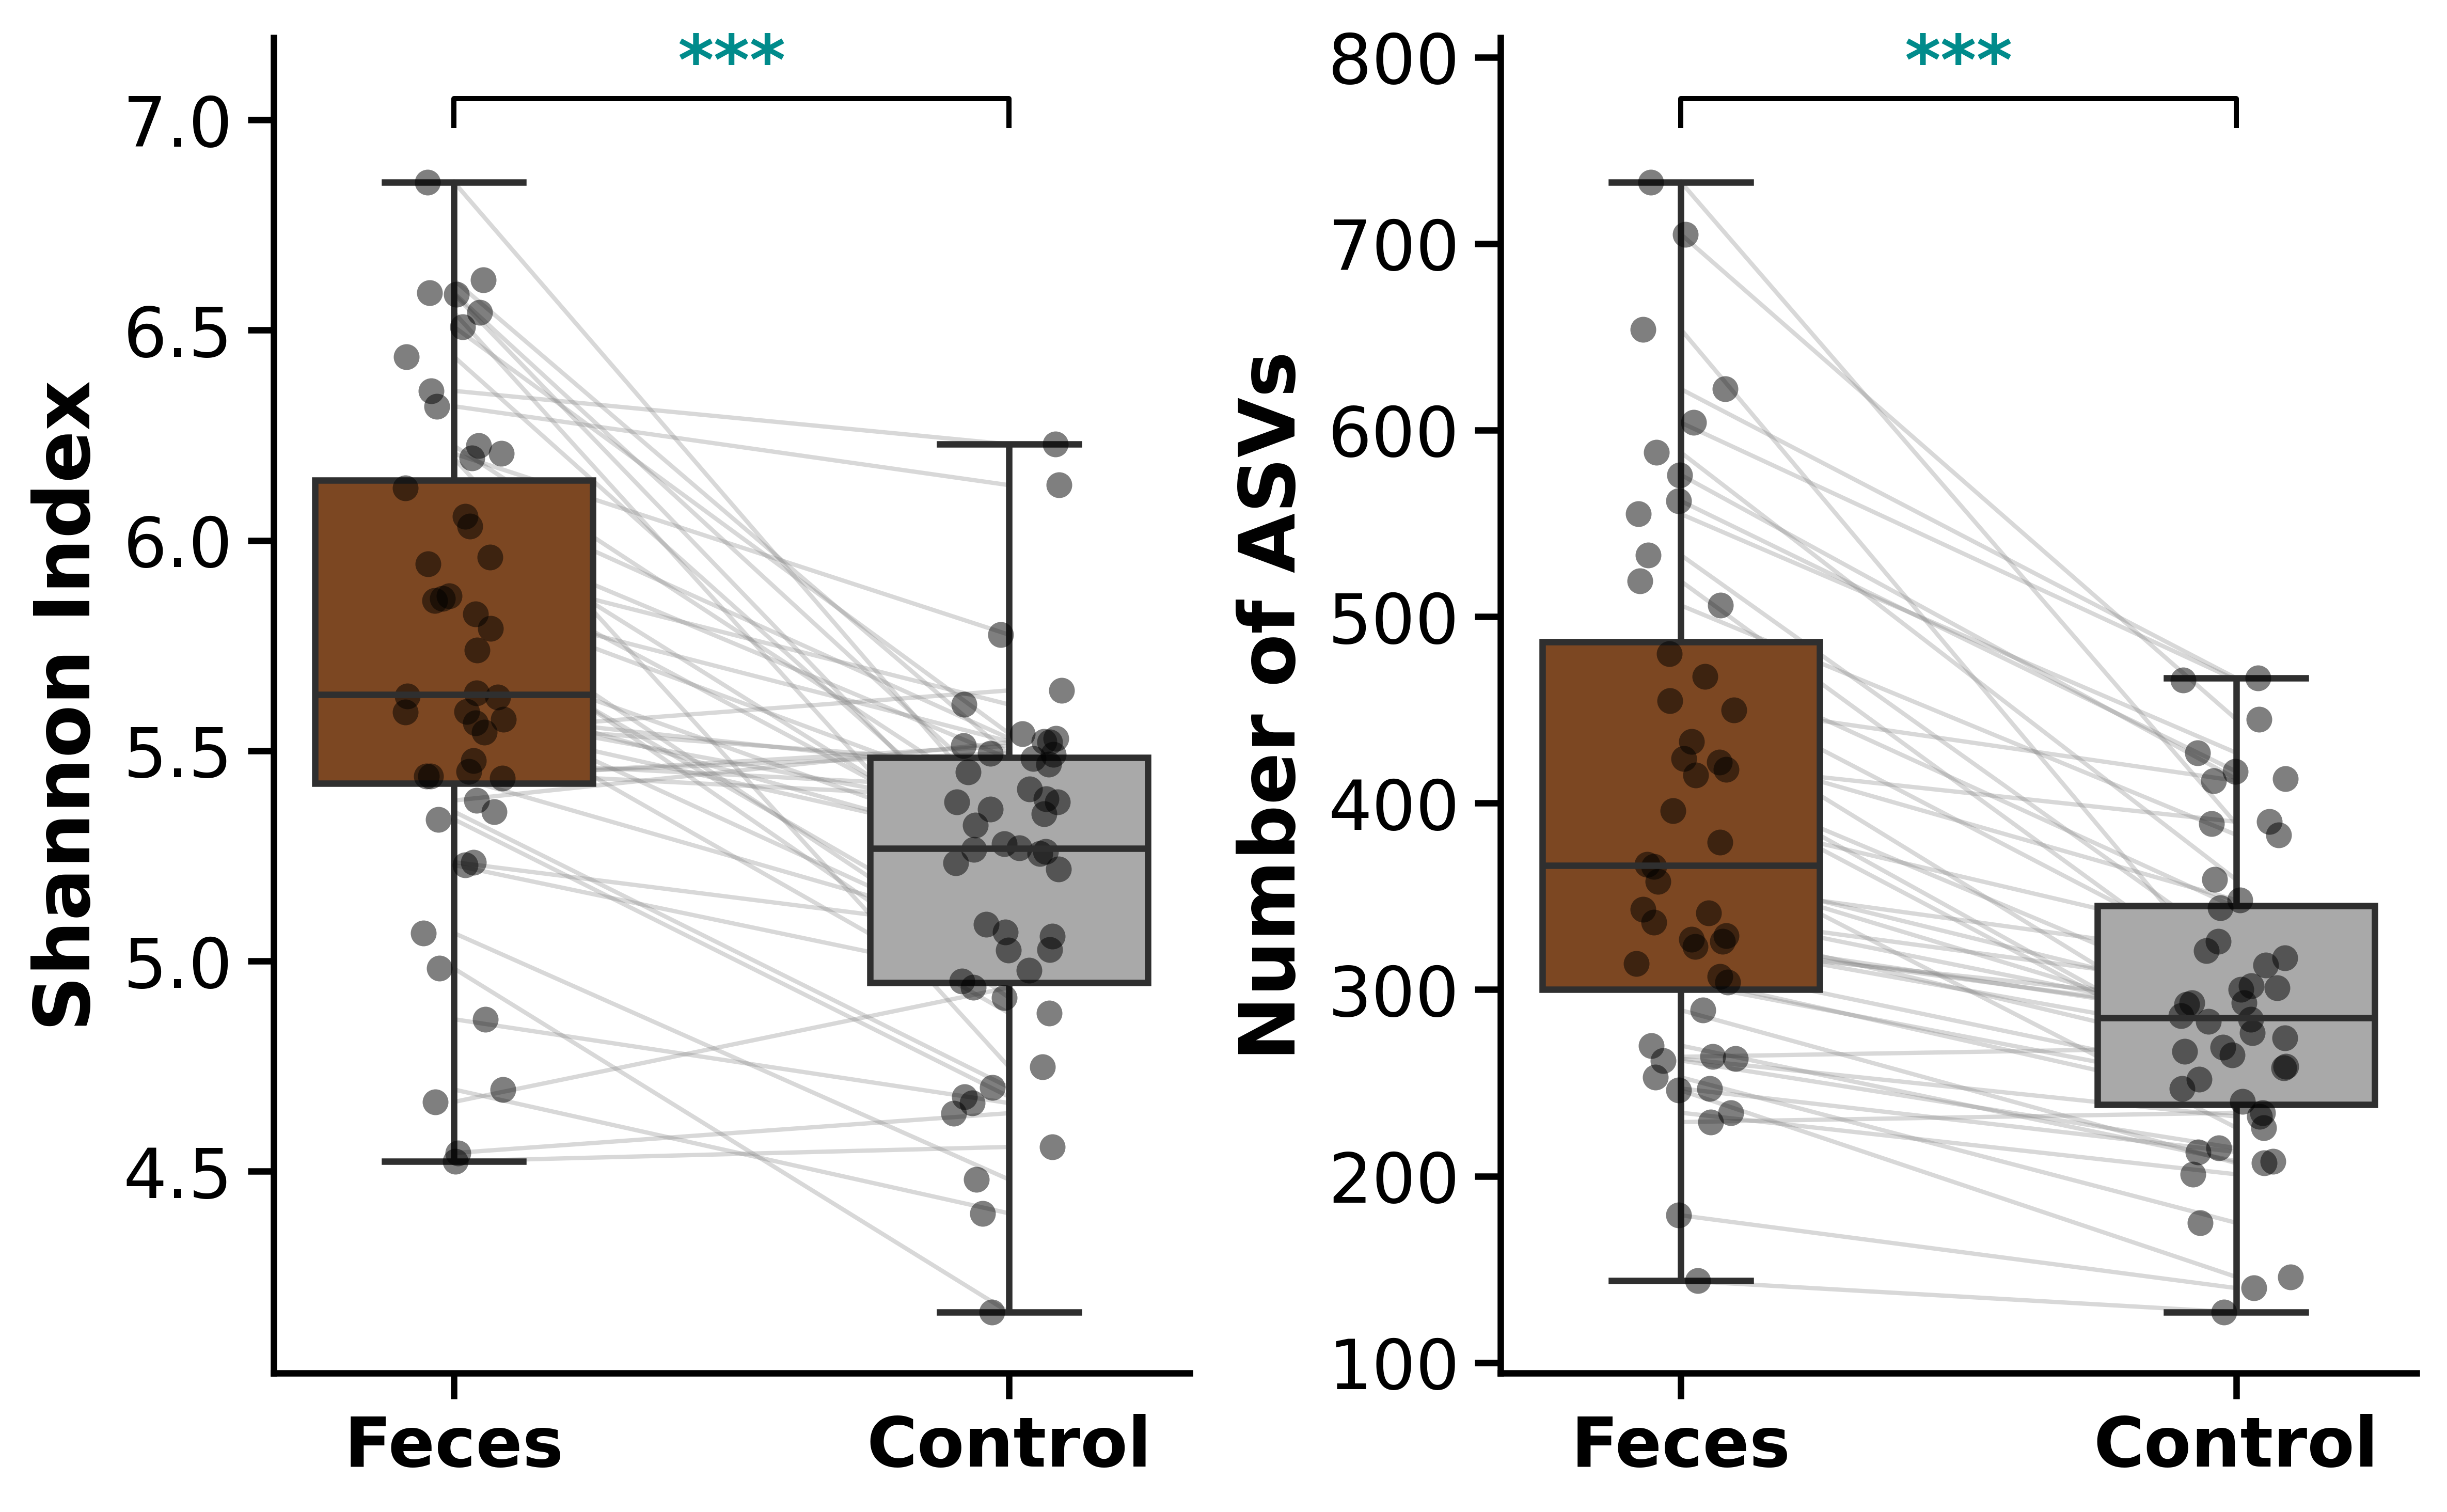

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

DPI_SETTING = 600

df_shannon = pd.read_csv("(KULFFI)_Shannon.csv")
df_asv = pd.read_csv("(KULFFI)_observed_ASV.csv")

def get_max_diversity(df):
    iter_cols = [c for c in df.columns if 'iter' in c]
    return df[iter_cols].max(axis=1)

df_shannon['Shannon'] = get_max_diversity(df_shannon)
df_asv['ASV'] = get_max_diversity(df_asv)

meta_sh = df_shannon[['Cluster', 'Feature', 'Shannon']].rename(columns={'Cluster':'Donor'})
meta_asv = df_asv[['Cluster', 'Feature', 'ASV']].rename(columns={'Cluster':'Donor'})

meta = pd.merge(meta_sh, meta_asv, on=['Donor', 'Feature'])
meta['Condition'] = meta['Feature'].map({'FEC': 'Feces', 'CUL': 'Control'})
meta = meta.dropna(subset=['Condition'])

df_pair = meta[meta['Condition'].isin(['Feces', 'Control'])]

pivot_sh = df_pair.pivot(index='Donor', columns='Condition', values='Shannon').dropna()
pivot_asv = df_pair.pivot(index='Donor', columns='Condition', values='ASV').dropna()

valid_donors = pivot_sh.index
df_pair = df_pair[df_pair['Donor'].isin(valid_donors)]

colors_s4a = {'Feces': '#8B4513', 'Control': '#A9A9A9'}

fig, axes = plt.subplots(1, 2, figsize=(8, 5), dpi=DPI_SETTING)

ax = axes[0]
sns.boxplot(x='Condition', y='Shannon', data=df_pair, order=['Feces', 'Control'],
            palette=colors_s4a, width=0.5, ax=ax, showfliers=False, linewidth=1.5)
sns.stripplot(x='Condition', y='Shannon', data=df_pair, order=['Feces', 'Control'],
              color='black', alpha=0.5, size=6, jitter=True, ax=ax, zorder=2)

for d in valid_donors:
    ax.plot([0, 1], [pivot_sh.loc[d, 'Feces'], pivot_sh.loc[d, 'Control']],
            color='gray', alpha=0.3, linewidth=1.0, zorder=1)

y_max_sh = df_pair['Shannon'].max()
y_range_sh = y_max_sh - df_pair['Shannon'].min()
current_y_sh = y_max_sh + (y_range_sh * 0.05)
step_sh = y_range_sh * 0.12

ax.plot([0, 0, 1, 1], [current_y_sh, current_y_sh + step_sh*0.2, current_y_sh + step_sh*0.2, current_y_sh], lw=1.2, c='black')
ax.text(0.5, current_y_sh + step_sh*0.2, '***', ha='center', va='bottom', color='#008B8B', fontsize=16, fontweight='bold')

ax.set_ylabel("Shannon Index", fontsize=18, fontweight='bold')
ax.set_xlabel("")

ax = axes[1]
sns.boxplot(x='Condition', y='ASV', data=df_pair, order=['Feces', 'Control'],
            palette=colors_s4a, width=0.5, ax=ax, showfliers=False, linewidth=1.5)
sns.stripplot(x='Condition', y='ASV', data=df_pair, order=['Feces', 'Control'],
              color='black', alpha=0.5, size=6, jitter=True, ax=ax, zorder=2)

for d in valid_donors:
    ax.plot([0, 1], [pivot_asv.loc[d, 'Feces'], pivot_asv.loc[d, 'Control']],
            color='gray', alpha=0.3, linewidth=1.0, zorder=1)

y_max_asv = df_pair['ASV'].max()
y_range_asv = y_max_asv - df_pair['ASV'].min()
current_y_asv = y_max_asv + (y_range_asv * 0.05)
step_asv = y_range_asv * 0.12

ax.plot([0, 0, 1, 1], [current_y_asv, current_y_asv + step_asv*0.2, current_y_asv + step_asv*0.2, current_y_asv], lw=1.2, c='black')
ax.text(0.5, current_y_asv + step_asv*0.2, '***', ha='center', va='bottom', color='#008B8B', fontsize=16, fontweight='bold')

ax.set_ylabel("Number of ASVs", fontsize=18, fontweight='bold')
ax.set_xlabel("")

sns.despine(trim=False)

for ax in axes:
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=16, width=1.5, length=6)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('Supplementary_Figure_S2a.pdf', bbox_inches='tight')